In [10]:
import pandas as pd
df_atac = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_202401021.csv',index_col=0 )

df_ml = pd.read_csv('allele_clustering/normalized_snp_ml_cluster_20241102_5cluster_fixed.csv',index_col=0)
df_ml['SNP_Function_ATAC'] = df_atac['SNP_Function']
df_ml_immune = df_ml[(df_ml['Cluster']==1)|(df_ml['Cluster']==2)]
df_ml_brain = df_ml[(df_ml['Cluster']==3)|(df_ml['Cluster']==4)]
df_ml_other = df_ml[df_ml['Cluster']==0]

df_ml.loc[df_ml_brain.index,'ML_Cluster'] = "Brain"
df_ml.loc[df_ml_immune.index,'ML_Cluster'] = "Immune"
df_ml.loc[df_ml_other.index,'ML_Cluster'] = "Non-specific"

In [2]:
df_atac 

,Type,RSID,Contributor,nearest_gene,rsID,chr_number,pos_hg38,r2,D',is_query_snp,...,ML_majormino_logFC_Mouse_Striatum_AgeB,ML_majormino_logFC_Mouse_Striatum_AgeC,ML_majormino_logFC_THP1_IFNB-Calvin_20,ML_majormino_logFC_THP1_IFNG-Calvin_20,ML_majormino_logFC_THP1_LPSIFNG-Calvin,ML_majormino_logFC_THP1_Naive-Calvin_2,ML_majormino_logFC_THP1_monocyte0729_2,variant_id,Bellenguez_p_value,Bellenguez_p_value_negLog10
alt:cg03073402:SNPCENTER:chr19:42927676:C:G:42927563:42927789:42927676,AD,cg03073402,Bertram,LIPE,cg03073402,19,42423524,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,-0.12,NaN,NaN,NaN,NaN
alt:cg03169557:SNPCENTER:chr16:89598950:C:G:89598837:89599063:89598950,AD,cg03169557,Bertram,SPG7,cg03169557,16,89532542,NaN,NaN,NaN,...,0.12,0.17,0.11,0.13,NaN,0.11,NaN,NaN,NaN,NaN
alt:cg05030077:SNPCENTER:chr16:2255199:C:G:2255086:2255312:2255199,AD,cg05030077,Bertram,MLST8,cg05030077,16,2205198,NaN,NaN,NaN,...,NaN,NaN,0.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
alt:cg05066959:SNPCENTER:chr8:41519308:C:G:41519195:41519421:41519308,AD,cg05066959,Bertram,ANK1,cg05066959,8,41661790,NaN,NaN,NaN,...,0.18,0.23,NaN,NaN,NaN,NaN,0.51,NaN,NaN,NaN
alt:cg05228284:SNPCENTER:chr19:2720847:C:G:2720734:2720960:2720847,AD,cg05228284,Bertram,DIRAS1,cg05228284,19,2720849,NaN,NaN,NaN,...,0.21,0.21,0.74,0.52,0.86,NaN,0.25,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
alt:rs9478143:PEAKCENTER:chr6:150862035:A:G:150861632:150862271:150862051,AD,rs9478143,Tanzi,MTHFD1L,rs9478143,6,150862035,1.0,1.0,1.0,...,-0.14,-0.14,NaN,NaN,NaN,NaN,NaN,rs9478143,9.793000e-01,0.009084
alt:rs953471:PEAKCENTER:chr9:124221903:G:A:124221758:124221963:124221854,AD,rs953471,Tanzi,NEK6,rs953471,9,124221903,1.0,1.0,1.0,...,0.19,0.17,NaN,0.11,0.20,NaN,NaN,rs953471,6.716000e-01,0.172889
alt:rs965034941:SNPCENTER:chr19:1999195:CCA:C:1999082:1999308:1999195,AD,rs965034941,Tanzi,BTBD2,rs965034941,19,1999195,NaN,NaN,NaN,...,0.10,NaN,NaN,NaN,0.15,-0.15,NaN,NaN,NaN,NaN
alt:rs983392:PEAKCENTER:chr11:59923508:A:G:59923333:59923833:59923583,AD,rs983392,Pfenning,MS4A6A,rs983392,11,60156035,1.0,1.0,1.0,...,NaN,-0.10,NaN,NaN,NaN,NaN,NaN,rs983392,2.260000e-17,16.646468


Chi-square: 13.995563974030874
p-value: 0.00730922715324476
Degrees of freedom: 4


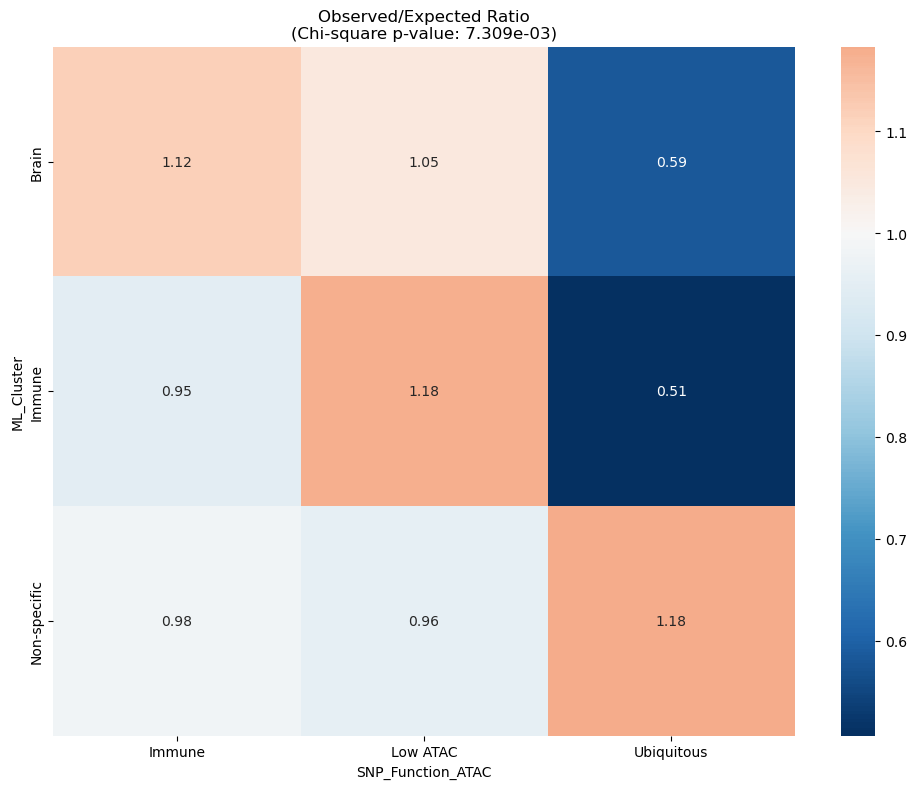

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Create contingency table with swapped axes:
observed = pd.crosstab(df_ml['ML_Cluster'], df_ml['SNP_Function_ATAC'])

# Perform a Chi-square test of independence on the contingency table
chi2, p, dof, expected_chi = chi2_contingency(observed)
print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

# You can compare `expected_chi` from the chi-square test directly to observed.
# If you want to use the previously computed expected counts as before:
row_sums = observed.sum(axis=1)
col_sums = observed.sum(axis=0)
total = observed.values.sum()

expected = pd.DataFrame(index=observed.index, columns=observed.columns, dtype=float)
for i in observed.index:
    for j in observed.columns:
        expected.loc[i, j] = (row_sums[i] * col_sums[j]) / total

# Compute observed/expected ratio
obs_over_exp = observed / expected

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(obs_over_exp, annot=True, fmt=".2f", cmap="RdBu_r", center=1.0)
plt.title("Observed/Expected Ratio\n(Chi-square p-value: {:.3e})".format(p))
plt.xlabel("SNP_Function_ATAC")
plt.ylabel("ML_Cluster")

# Adjust layout and save at high resolution
plt.tight_layout()
plt.savefig("heatmap.pdf", dpi=300)
plt.show()


In [11]:
df_mpra = pd.read_csv("allele_clustering/normalized_snp_ml_cluster_fixed_20250324_5cluster_customsort.csv", index_col=0)
df_mpra_immune = df_mpra[(df_mpra['Cluster']==2)|(df_mpra['Cluster']==3)]
df_mpra_brain = df_mpra[(df_mpra['Cluster']==1)|(df_mpra['Cluster']==0)]
df_mpra_other = df_mpra[df_mpra['Cluster']==4]

df_ml.loc[df_mpra_brain.index,'MPRA_Cluster'] = "Brain"
df_ml.loc[df_mpra_immune.index,'MPRA_Cluster'] = "Immune"
df_ml.loc[df_mpra_other.index,'MPRA_Cluster'] = "Non-specific"

Chi-square: 2.5776042153678125
p-value: 0.6307955212294358
Degrees of freedom: 4


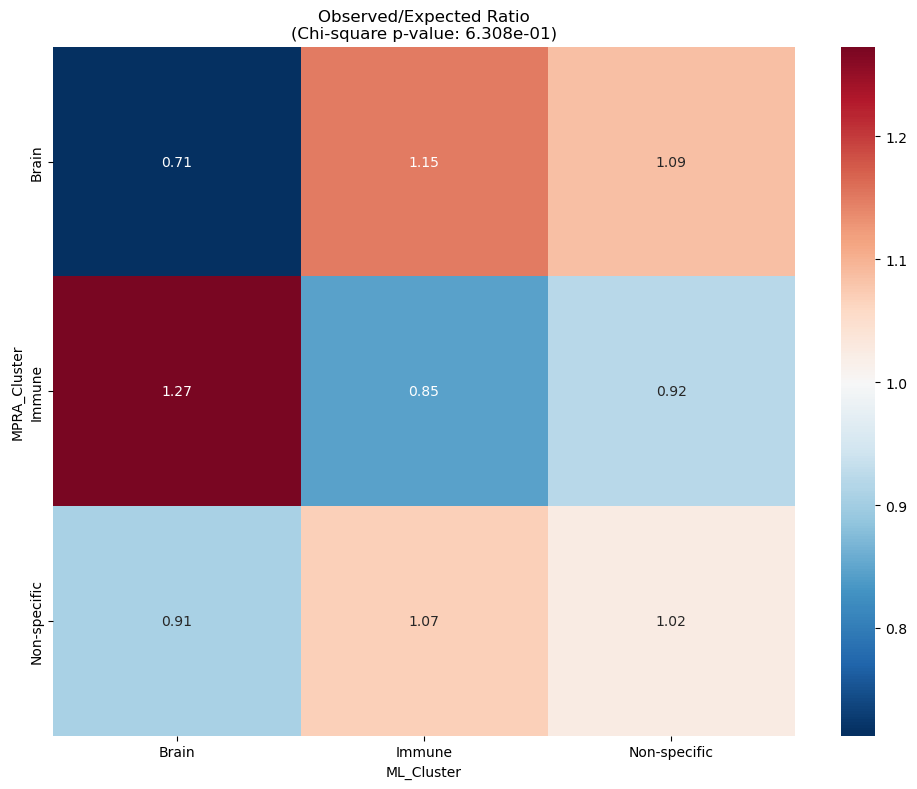

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Create contingency table with swapped axes:
observed = pd.crosstab(df_ml['MPRA_Cluster'], df_ml['ML_Cluster'])

# Perform a Chi-square test of independence on the contingency table
chi2, p, dof, expected_chi = chi2_contingency(observed)
print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

# You can compare `expected_chi` from the chi-square test directly to observed.
# If you want to use the previously computed expected counts as before:
row_sums = observed.sum(axis=1)
col_sums = observed.sum(axis=0)
total = observed.values.sum()

expected = pd.DataFrame(index=observed.index, columns=observed.columns, dtype=float)
for i in observed.index:
    for j in observed.columns:
        expected.loc[i, j] = (row_sums[i] * col_sums[j]) / total

# Compute observed/expected ratio
obs_over_exp = observed / expected

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(obs_over_exp, annot=True, fmt=".2f", cmap="RdBu_r", center=1.0)
plt.title("Observed/Expected Ratio\n(Chi-square p-value: {:.3e})".format(p))
plt.xlabel('ML_Cluster')
plt.ylabel('MPRA_Cluster')

# Adjust layout and save at high resolution
plt.tight_layout()
plt.savefig("expected_mpra_ml_heatmap.pdf", dpi=300)
plt.show()


In [10]:
observed

SNP_Function_ATAC,Immune,Low ATAC,Ubiquitous
MPRA_Cluster,,,
Brain,161,245,80
Immune,72,101,27
Non-specific,47,98,24


Chi-square: 5.160243978619514
p-value: 0.2712470867569988
Degrees of freedom: 4


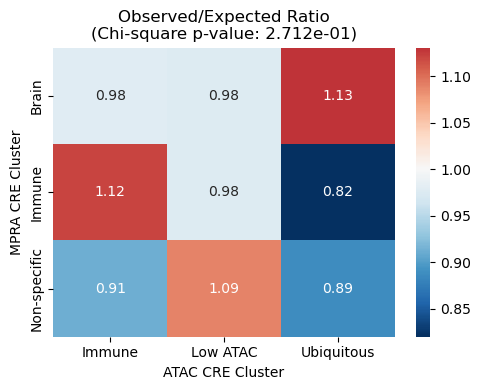

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Create contingency table with swapped axes:
observed = pd.crosstab(df_ml['MPRA_Cluster'], df_ml['SNP_Function_ATAC'])

# Perform a Chi-square test of independence on the contingency table
chi2, p, dof, expected_chi = chi2_contingency(observed)
print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

# You can compare `expected_chi` from the chi-square test directly to observed.
# If you want to use the previously computed expected counts as before:
row_sums = observed.sum(axis=1)
col_sums = observed.sum(axis=0)
total = observed.values.sum()

expected = pd.DataFrame(index=observed.index, columns=observed.columns, dtype=float)
for i in observed.index:
    for j in observed.columns:
        expected.loc[i, j] = (row_sums[i] * col_sums[j]) / total

# Compute observed/expected ratio
obs_over_exp = observed / expected

# Plot the heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(obs_over_exp, annot=True, fmt=".2f", cmap="RdBu_r", center=1.0)
plt.title("Observed/Expected Ratio\n(Chi-square p-value: {:.3e})".format(p))
plt.xlabel("ATAC CRE Cluster")
plt.ylabel("MPRA CRE Cluster")

# Adjust layout and save at high resolution
plt.tight_layout()
plt.savefig("expected_mpra_atac_heatmap.pdf", dpi=300)
plt.show()


In [5]:
df_mpra

,HMC3_IFNB_MPRA,HMC3_IFNG_MPRA,THP1_IFNB_MPRA,THP1_IFNG_MPRA,BrainR1R2merged20240404_Cortex_MPRA,BrainR1R2merged20240404_Hippocampus_MPRA,BrainR1R2merged20240404_Striatum_MPRA,HMC3_LPSIFNG_MPRA,HMC3_Naive_MPRA,THP1_LPSIFNG_MPRA,THP1_Naive_MPRA,Cluster
alt:rs11079866:PEAKCENTER:chr17:47324485:T:C:47324298:47324555:47324420,-0.089129,0.023932,0.687386,1.370556,-0.273034,-0.272499,-0.997795,0.384650,0.197743,0.357335,0.842595,0
alt:rs672399:PEAKCENTER:chr11:60020112:T:G:60018954:60020211:60020089,1.479665,0.849336,-0.804929,-0.355110,-0.401651,-0.315966,-1.036544,1.131416,-0.263795,-0.891900,-0.390949,0
alt:rs573338217:SNPCENTER:chr1:101453823:C:G:101453710:101453936:101453823,-0.699198,0.248075,0.264195,0.309587,-0.601197,-0.425784,-0.795469,-0.791745,0.437031,-0.310969,0.207940,0
alt:rs953471:PEAKCENTER:chr9:124221903:G:A:124221758:124221963:124221854,-0.087138,0.104590,0.163646,0.901160,-0.958110,-1.109819,0.116512,0.396628,0.544888,0.891031,0.547255,0
alt:rs10736701:PEAKCENTER:chr11:60031476:C:T:60030928:60031502:60031453,-0.777170,-0.055715,0.095797,0.288060,-0.159589,-0.349913,-1.705261,-0.544996,-1.314429,-0.559916,0.302734,0
...,...,...,...,...,...,...,...,...,...,...,...,...
alt:rs748160380:PEAKCENTER:chr6:6003700:T:C:6003387:6004225:6003746,0.485829,0.537210,0.618751,0.102399,0.267514,0.566532,0.048210,0.101625,-0.113117,1.561252,1.270711,4
alt:rs75009307:PEAKCENTER:chr12:45050225:A:G:45049885:45050385:45050135,0.684717,-0.144293,0.187943,-0.068510,1.372825,0.199502,0.746944,0.593941,0.677455,0.036371,0.764914,4
alt:rs7933202:PEAKCENTER:chr11:59936926:A:C:59936720:59937220:59936970,1.147056,0.510530,0.510488,0.115678,0.665035,1.570553,1.017215,0.434986,0.307783,-0.632745,0.499530,4
alt:rs80057954:PEAKCENTER:chr2:113083542:T:C:113083120:113083680:113083527,0.742889,0.207794,0.818275,1.657721,0.130373,0.302820,0.443079,0.785227,0.141557,1.595943,1.136708,4


Chi-square: 4.82190758166051
p-value: 0.3060637594285617
Degrees of freedom: 4


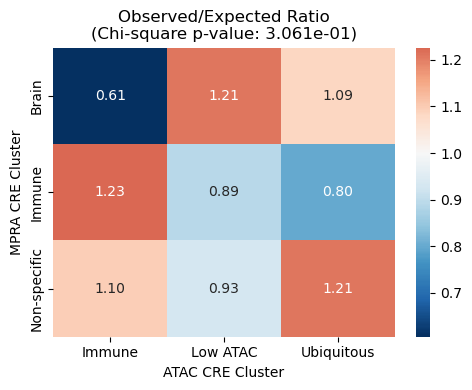

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

df_mpra = pd.read_csv("allele_clustering/normalized_snp_ml_cluster_fixed_20250324_5cluster_customsort.csv", index_col=0)
df_mpra_immune = df_mpra[(df_mpra['Cluster']==2)|(df_mpra['Cluster']==3)]
df_mpra_brain = df_mpra[(df_mpra['Cluster']==1)|(df_mpra['Cluster']==0)]
df_mpra_other = df_mpra[df_mpra['Cluster']==4]

import pandas as pd
df_atac = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_MAFCorrect_20250617.csv',index_col=0 )

df_mpra = pd.merge(df_mpra , df_atac['SNP_Function'],left_index=True,right_index=True)

df_mpra .loc[df_mpra_brain.index,'MPRA_Cluster'] = "Brain"
df_mpra .loc[df_mpra_immune.index,'MPRA_Cluster'] = "Immune"
df_mpra .loc[df_mpra_other.index,'MPRA_Cluster'] = "Non-specific"

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Create contingency table with swapped axes:
observed = pd.crosstab(df_mpra ['MPRA_Cluster'], df_mpra ['SNP_Function'])

# Perform a Chi-square test of independence on the contingency table
chi2, p, dof, expected_chi = chi2_contingency(observed)
print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

# You can compare `expected_chi` from the chi-square test directly to observed.
# If you want to use the previously computed expected counts as before:
row_sums = observed.sum(axis=1)
col_sums = observed.sum(axis=0)
total = observed.values.sum()

expected = pd.DataFrame(index=observed.index, columns=observed.columns, dtype=float)
for i in observed.index:
    for j in observed.columns:
        expected.loc[i, j] = (row_sums[i] * col_sums[j]) / total

# Compute observed/expected ratio
obs_over_exp = observed / expected

# Plot the heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(obs_over_exp, annot=True, fmt=".2f", cmap="RdBu_r", center=1.0)
plt.title("Observed/Expected Ratio\n(Chi-square p-value: {:.3e})".format(p))
plt.xlabel("ATAC CRE Cluster")
plt.ylabel("MPRA CRE Cluster")

# Adjust layout and save at high resolution
plt.tight_layout()
plt.savefig("expected_mpra_atac_heatmap_new.pdf", dpi=300)
plt.show()
